In [57]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [58]:
from collections import Counter
from collections import defaultdict

import numpy as np
import pandas as pd
from sqlalchemy import Integer
from sqlalchemy import create_engine
from sqlalchemy import func
from sqlalchemy.orm import Query
from sqlalchemy.orm import Session
from sqlalchemy.orm import joinedload
from sqlalchemy.orm import load_only
from sqlalchemy.orm import subqueryload

import src
from src import party_names
from src.data.models import Channel
from src.data.models import Sentence
from src.data.models import Video

In [59]:
pd.set_option("display.max_rows", 256)
engine = create_engine(src.PS_ENGINE)

In [60]:
MIN_CONFIDENCE = 0.5

# Most common manifesto_classes

In [61]:
query = (
    Query(Channel)
    .join(Video)
    .join(Sentence)
    .filter(
        Sentence.is_valid == True,
        Sentence.manifesto_confidence > MIN_CONFIDENCE,
        )
    .group_by(Sentence.manifesto_class)
    .with_entities(
         Sentence.manifesto_class, func.count(Sentence.id).label("count"),
    )
)
with engine.connect() as conn:
    df = pd.read_sql(query.statement, conn)

In [62]:
df["rel"] = df["count"] / df["count"].sum()
df.sort_values("count", ascending=False).head()

,manifesto_class,count,rel
18,305 - Political Authority,164177,0.378654
35,501 - Environmental Protection: Positive,22172,0.051137
29,411 - Technology and Infrastructure,17125,0.039497
11,202 - Democracy,17031,0.039280
36,502 - Culture: Positive,16426,0.037885


# Most common manifesto classes on populist sentences

In [63]:
with Session(engine) as s:
    videos = (
        s.query(Video)
        .options(
            load_only(Video.id),
            joinedload(Video.channel).load_only(Channel.channel),
            subqueryload(Video.sentences).defer(Sentence.tokens, Sentence.sentence_no),
        )
        .filter(Video.is_valid == True)
    )

    c = defaultdict(lambda: defaultdict(int))
    for video in videos:
        for sent in video.sentences:
            if sent.pplcentr == True or sent.elite == True:
                if sent.manifesto_confidence > .5:
                    c[video.channel.channel][sent.manifesto_class] += 1

In [64]:
df = pd.DataFrame(
    [(channel, class_, count) for channel, d in c.items() for class_, count in d.items()],
    columns=["channel", "manifest_class", "count"],
).sort_values(["channel", "count"], ascending=[True, False])

df = df.loc[df.manifest_class != "305 - Political Authority",:]
df.channel = df.channel.replace(party_names)

In [65]:
populist_manifesto_classes = df.groupby("channel").head(5).set_index("channel")

In [66]:
tex = populist_manifesto_classes.style.set_table_styles(
    [
        {"selector": "toprule", "props": ":toprule;"},
        {"selector": "bottomrule", "props": ":bottomrule;"},
    ],
).to_latex()

def add_bold_font(text):
    return r"\textbf{" + text + "}"

lines = tex.splitlines()

new = []
for i, line in enumerate(lines, 1):
    if i == 1:
        line = (
            r"\begin{longtable}{llr}" + "\n"
            r"\caption{Count of labels and manifesto classes per party for sentences that are "
            r"either anti-elitist or people-centric.}\\" + "\n"
        )
    if i == len(lines):
        line = "\end{longtable}"
    if i == 3:
        line = r"""Channel & Manifesto Class & Count \\
\midrule
\endhead
"""
    if i == 4:
        continue

    if i >= 5 and i < 45:
        cells = line.split("&")
        if not i % 5:
            if i > 6:
                new.append(r" & & \\")
            cells[0] = add_bold_font(cells[0])
        else:
            cells[0] = ""
        line = "&".join(cells)
    
    if i == len(lines):
        new.append( r"\label{tab:manifesto}" + "\n")

    new.append(line)


tex = "\n".join(new)

(src.PATH / "overleaf/tables/populist_manifesto_classes.tex").write_text(tex)

# print(tex)

2080

# Most common manifesto classes and populism on videos


- do not use. not very clever. aggregation on the video level makes the numbers very small

In [67]:
with Session(engine) as s:
    videos = (
        s.query(Video)
        .options(
            load_only(Video.id),
            joinedload(Video.channel).load_only(Channel.channel),
            subqueryload(Video.sentences).defer(Sentence.tokens, Sentence.sentence_no),
        )
        .filter(Video.is_valid == True)
    )

    rows = []
    for video in videos:
        channel = video.channel.channel
        sents = [sent for sent in video.sentences if sent.is_valid == True]
        if len(sents) < 5:
            continue
        most_common_manifesto = Counter(
            [sent.manifesto_class for sent in sents if sent.manifesto_confidence > 0.5],
        ).most_common(1)
        try:
            most_common_manifesto = most_common_manifesto[0][0]
        except IndexError:
            most_common_manifesto = None

        elite = np.nanmean([sent.elite for sent in sents])
        pplcentr = np.nanmean([sent.pplcentr for sent in sents])
        populism = elite * pplcentr
        row = (channel, most_common_manifesto, populism)
        rows.append(row)

In [68]:
df = pd.DataFrame(rows, columns=["channel", "manifesto", "populism"])
df.channel = df.channel.replace(party_names)

In [69]:
df = df.sort_values(["channel", "populism"], ascending=False)
df.groupby(["channel", "manifesto"]).populism.mean().reset_index().sort_values(
    ["channel", "populism"], ascending=False,
).groupby("channel").head(5)

,channel,manifesto,populism
207,SPD,201 - Freedom and Human Rights,0.007574
224,SPD,605 - Law and Order: Positive,0.001927
225,SPD,606 - Civic Mindedness: Positive,0.001315
212,SPD,305 - Political Authority,0.001182
219,SPD,504 - Welfare State Expansion,0.000991
180,Left,108 - European Community/Union: Positive,0.038425
190,Left,412 - Controlled Economy,0.011834
183,Left,303 - Governmental and Administrative Efficiency,0.008264
194,Left,504 - Welfare State Expansion,0.005769
193,Left,503 - Equality: Positive,0.005679


# Populism over time

In [70]:
sentence_query = (
    Query(Sentence)
    .filter(Sentence.is_valid == True)
    .group_by(Sentence.video_id)
    .with_entities(
        Sentence.video_id,
        func.avg(Sentence.elite.cast(Integer)).label("elite"),
        func.avg(Sentence.pplcentr.cast(Integer)).label("pplcentr"),
        func.avg(Sentence.left.cast(Integer)).label("left"),
        func.avg(Sentence.right.cast(Integer)).label("right"),
    )
    .subquery()
)

query = (
    Query(Channel)
    .join(Video)
    .filter(Video.is_valid == True)
    .group_by(Channel.channel, Video.id)
    .join(sentence_query, Video.id == sentence_query.c.video_id)
    .with_entities(
        Channel.channel,
        Video.datetime_upload,
        func.avg(sentence_query.c.elite).label("elite"),
        func.avg(sentence_query.c.pplcentr).label("pplcentr"),
        func.avg(sentence_query.c.left).label("left"),
        func.avg(sentence_query.c.right).label("right"),
    )
)


with engine.connect() as conn:
    df = pd.read_sql(query.statement, conn)

df.channel = df.channel.replace(party_names)
df.datetime_upload = pd.to_datetime(df.datetime_upload)
df = df.sort_values(["channel", "datetime_upload"]).set_index("datetime_upload")

In [71]:
df_month = (
    df.groupby("channel")
    .resample("ME")
    .mean()
    .fillna(0)
    .rolling(window=12, min_periods=1)
    .mean(numeric_only=True)
    .reset_index()
)

In [72]:
df_long = pd.melt(
    df_month,
    id_vars=["channel", "datetime_upload"],
    var_name="variable",
    value_vars=[
        "elite",
        "pplcentr",
        "left",
        "right",
    ],
)


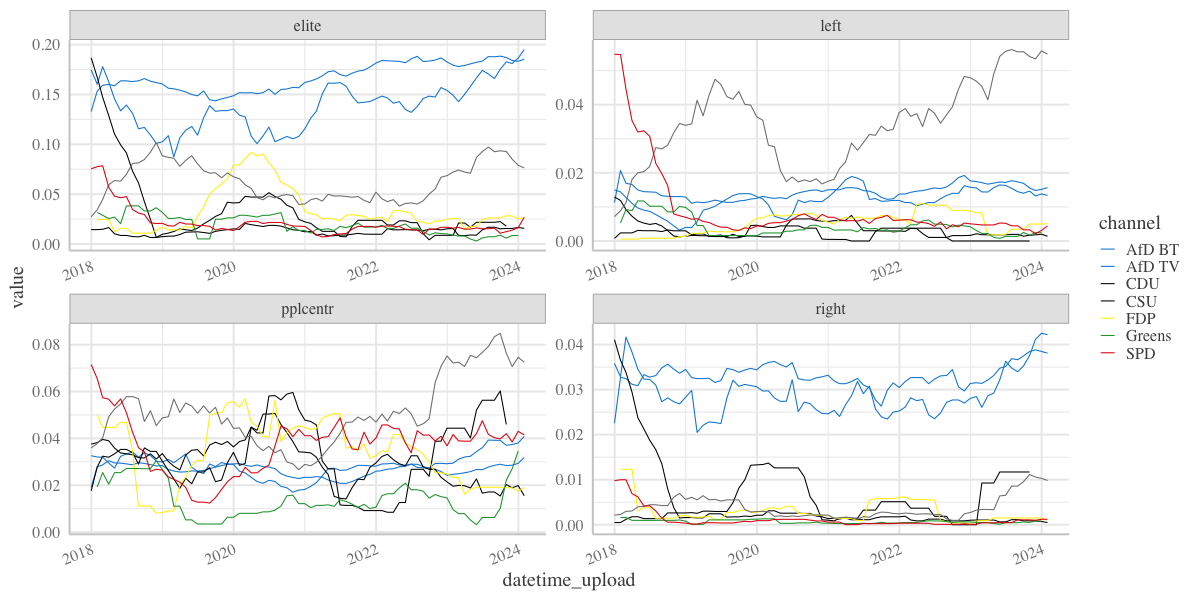

In [73]:
%%R -i df_long -i r_colormap -w 1200 -h 600

library(tidyverse)
library(ggeffects)
library(ggplot2)

cmap <- setNames(r_colormap$color, r_colormap$channel)

ggplot(df_long, aes(x=datetime_upload, y=value, color=channel)) +
    geom_line() +
    scale_color_manual(values=cmap) +
    facet_wrap("~variable", scales="free", ncol=2) +
    theme_ggeffects(base_family="serif", base_size=20) +
    theme(axis.text.x = element_text(angle=20, hjust=1))